legacy notebook ts wont be updated im using an actual workspace now yay

In [ ]:
# seed dirs
!mkdir src
!mkdir include
!mkdir build

mkdir: cannot create directory ‘src’: File exists
mkdir: cannot create directory ‘include’: File exists
mkdir: cannot create directory ‘build’: File exists


In [ ]:
%%writefile src/main.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include "collections.h"

int main() {
    int NUM_NEURONS = 1;
    snn::neuron_creation_parameters<float> n_params;
    n_params.v_th = 1.0f;
    n_params.tau_rc = 0.02f;
    n_params.tau_ref = 0.002f;
    n_params.v_init = 0.0f;
    n_params.slf = true;
    n_params.tau_w = 0.3f;
    n_params.b = 0.2f;

    snn::range<float> max_rate_range = {200.0f, 400.0f};
    snn::range<float> intercept_range = {-1.0f, 1.0f};
    std::vector<float> encoders = {1.0f};

    auto* lifs = snn::neuron_collection_init<float>(NUM_NEURONS, n_params, max_rate_range, intercept_range, encoders);
    auto* synapses = snn::synapse_collection_init<float>(NUM_NEURONS, 0.01f);

    float T_step = 0.001f;
    float T_max = 5.0f;
    int total_steps = static_cast<int>(T_max / T_step);

    // Buffers to store internal state for visualization
    std::vector<float> v_log(total_steps);
    std::vector<float> v_th_log(total_steps);
    std::vector<float> out_log(total_steps);
    std::vector<float> in_log(total_steps, 1.3f);

    // Run simulation manually for single neuron logging
    for(int i=0; i < total_steps; ++i) {
        in_log[i] = 1.3f;
        v_th_log[i] = lifs->neurons[0]->s->v_th + lifs->neurons[0]->s->w;
        out_log[i] = snn::neuron_forward(lifs->neurons[0]->s, in_log[i], T_step);
        v_log[i] = lifs->neurons[0]->s->v;
    }

    std::ofstream out("output.csv");
    out << "step,input,v,v_th_eff,spike\n";
    for(int i=0; i < total_steps; ++i) {
        out << i << "," << in_log[i] << "," << v_log[i] << "," << v_th_log[i] << "," << out_log[i] << "\n";
    }
    out.close();

    std::cout << "Single neuron data saved to output.csv" << std::endl;
    return 0;
}

Overwriting src/main.cpp


In [ ]:
%%writefile include/neuron.h
#ifndef SNN_NEURON_H
#define SNN_NEURON_H

#include <vector>
#include <cuda_runtime.h>

namespace snn {
  template<typename T>
  struct neuron_state {
    T
     v, // membrane potential
     v_th, // membrane potential threshold for spike
     tau_rc, // membrane potential decay constant
     tau_ref, // time to rest after fire
     rest_time, // neuron rest time until neuron can spike again
     w, // how much v_th changed
     tau_w, // how w should evolve over time
     b; // how much to increase w after neuron spike
    bool slf = false; // if true, when v > v_th, v -= v_th, else, v = 0
  };

  template<typename T>
  struct neuron_parameters {
    T a, b, e;
  };

  template<typename T>
  struct neuron {
    neuron_state<T> *s;
    neuron_parameters<T> *p;
  };

  template<typename T>
  struct neuron_creation_parameters {
    T v_th, tau_rc, tau_ref, v_init, tau_w, b = T{};
    bool slf = false;
  };

  template<typename T>
  struct gain_bias {
    T gain, bias;
  };

  template<typename T>
  neuron_state<T> *neuron_init(neuron_creation_parameters<T> params);

  template<typename T>
  __host__ __device__ T neuron_forward(neuron_state<T> *n, T I, T T_step);

  template<typename T>
  __host__ __device__ T neuron_analytical_rate(neuron_state<T> *n, T I);

  template<typename T>
  gain_bias<T> neuron_get_gain_bias(neuron_state<T>* n, T max_rate, T intercept);
}

#endif

Overwriting include/neuron.h


In [ ]:
%%writefile src/neuron.cpp
#include "neuron.h"
#include <cmath>

namespace snn {
  template<typename T>
  neuron_state<T> *neuron_init(neuron_creation_parameters<T> params) {
    neuron_state<T> *n = new neuron_state<T>;
    n->v = params.v_init;
    n->v_th = params.v_th;
    n->tau_rc = params.tau_rc;
    n->tau_ref = params.tau_ref;
    n->rest_time = 0;
    n->slf = params.slf;
    n->tau_w = params.tau_w;
    n->b = params.b;
    n->w = 0;
    return n;
  }

  template<typename T>
  __host__ __device__ T neuron_forward(neuron_state<T> *n, T I, T T_step) {
    T output = T{0};
    T dt = T_step - n->rest_time < 0 ? 0 : T_step - n->rest_time > T_step ? T_step : T_step - n->rest_time;

    if (n->rest_time > 0) {
        n->rest_time -= T_step;
    } else {
        n->v = I + (n->v - I) * std::exp(-dt / n->tau_rc);
    }

    if (n->v >= n->v_th + n->w) {
      output = T{1} / dt;
      n->w += n->b;
      T st = dt + n->tau_rc * std::log((n->v - I) / (n->v_th - I));
      n->rest_time = n->tau_ref + st;
      n->v = n->slf ? n->v - n->v_th : T{0};
    }

    n->w = n->w * std::exp(-dt / n->tau_w) + n->b * (output > 0);
    return output;
  }

  template<typename T>
  __host__ __device__ T neuron_analytical_rate(neuron_state<T> *n, T I) {
    if (I <= n->v_th) return T{};
    else return T{1} / (n->tau_ref - n->tau_rc * log(1 - n->v_th/I));
  }

  template<typename T>
  gain_bias<T> neuron_get_gain_bias(neuron_state<T>* n, T max_rate, T intercept) {
    T term = (n->tau_ref - T{1}/max_rate) / n->tau_rc;
    T denom = T{1} - (T{1} / (T{1} - exp(term)));
    gain_bias<T> gb;
    gb.gain = (n->v_th * denom) / (intercept - T{1});
    gb.bias = n->v_th - gb.gain * intercept;
    return gb;
  }

  // Explicit instantiations ensure the compiler generates code for these types
  // so that the GPU linker can find them across translation units.
  template neuron_state<float>* neuron_init<float>(neuron_creation_parameters<float>);
  template __host__ __device__ float neuron_forward<float>(neuron_state<float>*, float, float);
  template __host__ __device__ float neuron_analytical_rate<float>(neuron_state<float>*, float);
  template gain_bias<float> neuron_get_gain_bias<float>(neuron_state<float>*, float, float);
}

Overwriting src/neuron.cpp


In [ ]:
%%writefile include/synapse.h
#ifndef SNN_SYNAPSE_H
#define SNN_SYNAPSE_H
#include <cuda_runtime.h>

namespace snn {
  template<typename T>
  struct synapse_state {
    T tau_s, g;
  };

  template<typename T>
  synapse_state<T> *synapse_init(T tau_s_);

  template<typename T>
  __host__ __device__ T synapse_forward(synapse_state<T> *s, T I, T T_step);
}
#endif

Overwriting include/synapse.h


In [ ]:
%%writefile src/synapse.cpp
#include "synapse.h"
#include <cmath>

namespace snn {
  template<typename T>
  synapse_state<T> *synapse_init(T tau_s_) {
    synapse_state<T> *s = new synapse_state<T>;
    s->tau_s = tau_s_;
    s->g = T{};
    return s;
  }

  template<typename T>
  __host__ __device__ T synapse_forward(synapse_state<T> *s, T I, T T_step) {
    s->g = I + std::exp(-T_step / s->tau_s) * (s->g - I);
    return s->g;
  }

  // Explicit template instantiations for the linker
  template synapse_state<float>* synapse_init<float>(float);
  template __host__ __device__ float synapse_forward<float>(synapse_state<float>*, float, float);
}

Overwriting src/synapse.cpp


In [ ]:
%%writefile include/collections.h
#ifndef SNN_COLLECTIONS_H
#define SNN_COLLECTIONS_H

#include "neuron.h"
#include "synapse.h"
#include "util.h"
#include <vector>

namespace snn {
  template<typename T>
  struct neuron_gpu_data {
    T *v, *v_th, *tau_rc, *tau_ref, *rest_time, *a, *b, *e;
    bool *slf;
  };

  template<typename T>
  struct synapse_gpu_data {
    T *tau_s, *g;
  };

  template<typename T>
  struct neuron_collection {
    std::vector<neuron<T>*> neurons;
    int size;
    neuron_gpu_data<T> device_data;
  };

  template<typename T>
  struct synapse_collection {
    std::vector<synapse_state<T>*> synapses;
    int size;
    synapse_gpu_data<T> device_data;
  };

  template<typename T>
  neuron_collection<T> *neuron_collection_init(int size, neuron_creation_parameters<T> n_p, range<T> max_rate_range_, range<T> intercept_range_, std::vector<T> encoder_choices_);

  template<typename T>
  synapse_collection<T> *synapse_collection_init(int size, T tau_s);

  template<typename T>
  void run_simulation_gpu(neuron_collection<T>* nc, synapse_collection<T>* sc, T* h_output_buffer, int steps, T T_step);
}
#endif

Overwriting include/collections.h


In [ ]:
%%writefile src/collections.cpp
#include "collections.h"
#include <cuda_runtime.h>

namespace snn {

void launch_full_sim(neuron_gpu_data<float> n, synapse_gpu_data<float> s, float* d_out, int size, int steps, float T_step);

template<typename T>
neuron_collection<T> *neuron_collection_init(int size, neuron_creation_parameters<T> n_p, range<T> max_rate_range_, range<T> intercept_range_, std::vector<T> encoder_choices_) {
    neuron_collection<T> *nc = new neuron_collection<T>;
    nc->size = size;
    cudaMalloc(&nc->device_data.v, size * sizeof(T));
    cudaMalloc(&nc->device_data.v_th, size * sizeof(T));
    cudaMalloc(&nc->device_data.tau_rc, size * sizeof(T));
    cudaMalloc(&nc->device_data.tau_ref, size * sizeof(T));
    cudaMalloc(&nc->device_data.rest_time, size * sizeof(T));
    cudaMalloc(&nc->device_data.a, size * sizeof(T));
    cudaMalloc(&nc->device_data.b, size * sizeof(T));
    cudaMalloc(&nc->device_data.e, size * sizeof(T));
    cudaMalloc(&nc->device_data.slf, size * sizeof(bool));

    std::vector<T> h_a(size), h_b(size), h_e(size), h_v(size, n_p.v_init), h_v_th(size, n_p.v_th), h_trc(size, n_p.tau_rc), h_trf(size, n_p.tau_ref), h_r(size, 0);
    // Use char/uint8_t for bool array to avoid std::vector<bool> pointer issues
    std::vector<uint8_t> h_slf(size, (uint8_t)n_p.slf);

    for (int i = 0; i < size; i++) {
        neuron<T> *n = new neuron<T>;
        n->s = neuron_init<T>(n_p);
        gain_bias<T> gb = neuron_get_gain_bias(n->s, util::random_uniform<T>(max_rate_range_.min, max_rate_range_.max), util::random_uniform<T>(intercept_range_.min, intercept_range_.max));
        n->p = new neuron_parameters<T>{gb.gain, gb.bias, util::random_choice<T>(encoder_choices_)};
        h_a[i] = n->p->a; h_b[i] = n->p->b; h_e[i] = n->p->e;
        nc->neurons.push_back(n);
    }

    cudaMemcpy(nc->device_data.v, h_v.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.v_th, h_v_th.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.tau_rc, h_trc.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.tau_ref, h_trf.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.rest_time, h_r.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.a, h_a.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.b, h_b.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.e, h_e.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(nc->device_data.slf, h_slf.data(), size * sizeof(bool), cudaMemcpyHostToDevice);
    return nc;
}

template<typename T>
synapse_collection<T> *synapse_collection_init(int size, T tau_s) {
    synapse_collection<T> *sc = new synapse_collection<T>;
    sc->size = size;
    cudaMalloc(&sc->device_data.g, size * sizeof(T));
    cudaMalloc(&sc->device_data.tau_s, size * sizeof(T));
    std::vector<T> h_g(size, 0), h_ts(size, tau_s);
    cudaMemcpy(sc->device_data.g, h_g.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    cudaMemcpy(sc->device_data.tau_s, h_ts.data(), size * sizeof(T), cudaMemcpyHostToDevice);
    return sc;
}

template<typename T>
void run_simulation_gpu(neuron_collection<T>* nc, synapse_collection<T>* sc, T* h_output, int steps, T T_step) {
    T* d_log;
    cudaMalloc(&d_log, nc->size * steps * sizeof(T));
    launch_full_sim(nc->device_data, sc->device_data, d_log, nc->size, steps, (float)T_step);
    cudaMemcpy(h_output, d_log, nc->size * steps * sizeof(T), cudaMemcpyDeviceToHost);
    cudaFree(d_log);
}

template void run_simulation_gpu<float>(neuron_collection<float>*, synapse_collection<float>*, float*, int, float);
template neuron_collection<float> *neuron_collection_init<float>(int, neuron_creation_parameters<float>, range<float>, range<float>, std::vector<float>);
template synapse_collection<float> *synapse_collection_init<float>(int, float);
}

Overwriting src/collections.cpp


In [ ]:
%%writefile include/weights.h
#ifndef SNN_WEIGHTS_H
#define SNN_WEIGHTS_H

namespace snn {
  template<typename T>
  struct sdtp_weights {

  };
}

#endif

In [ ]:
%%writefile include/util.h
#ifndef SNN_UTIL_H
#define SNN_UTIL_H

#include <vector>
#include <random>
#include <type_traits>

namespace snn {

  template<typename T>
  struct range {
    T min, max;
  };

  namespace util {
    // Random uniform distribution for floating point and integers
    template<typename T>
    T random_uniform(T min, T max);

    // Random choice from a vector
    template<typename T>
    T random_choice(const std::vector<T>& choices);
  }
}

#endif

Overwriting include/util.h


In [ ]:
%%writefile src/util.cpp
#include "util.h"
#include <stdexcept>
#include <chrono>

namespace snn {
  namespace util {
    static std::mt19937 gen(static_cast<unsigned int>(std::chrono::system_clock::now().time_since_epoch().count()));

    template<typename T>
    T random_uniform(T min, T max) {
      if constexpr (std::is_floating_point_v<T>) {
        std::uniform_real_distribution<T> dis(min, max);
        return dis(gen);
      } else {
        std::uniform_int_distribution<T> dis(min, max);
        return dis(gen);
      }
    }

    template<typename T>
    T random_choice(const std::vector<T>& choices) {
      if (choices.empty()) {
        throw std::runtime_error("random_choice called with empty vector");
      }
      std::uniform_int_distribution<size_t> dis(0, choices.size() - 1);
      return choices[dis(gen)];
    }

    // Explicit instantiations for common types
    template float random_uniform<float>(float, float);
    template double random_uniform<double>(double, double);
    template int random_uniform<int>(int, int);

    template float random_choice<float>(const std::vector<float>&);
    template int random_choice<int>(const std::vector<int>&);
  }
}

Overwriting src/util.cpp


In [ ]:
%%writefile src/kernel.cu
#include "collections.h"
#include <cuda_runtime.h>
#include <cmath>

namespace snn {

__global__ void snn_simulation_kernel(neuron_gpu_data<float> n_data, synapse_gpu_data<float> s_data, float* output_log, int num_neurons, int total_steps, float T_step) {
    int nid = blockIdx.x * blockDim.x + threadIdx.x;
    if (nid >= num_neurons) return;

    // Temporary objects to interface with shared neuron/synapse logic
    neuron_state<float> n;
    n.v = n_data.v[nid];
    n.v_th = n_data.v_th[nid];
    n.tau_rc = n_data.tau_rc[nid];
    n.tau_ref = n_data.tau_ref[nid];
    n.rest_time = n_data.rest_time[nid];
    n.slf = n_data.slf[nid];

    synapse_state<float> s;
    s.tau_s = s_data.tau_s[nid];
    s.g = s_data.g[nid];

    float a = n_data.a[nid];
    float b = n_data.b[nid];
    float e = n_data.e[nid];

    for (int step = 0; step < total_steps; ++step) {
        float t = step * T_step;
        float input_signal = sinf(t);
        float drive = (input_signal * a * e) + b;

        float spike = neuron_forward(&n, drive, T_step);
        float current = synapse_forward(&s, spike, T_step);

        output_log[step * num_neurons + nid] = current;
    }

    // Write final state back to global memory
    n_data.v[nid] = n.v;
    n_data.rest_time[nid] = n.rest_time;
    s_data.g[nid] = s.g;
}

void launch_full_sim(neuron_gpu_data<float> n, synapse_gpu_data<float> s, float* d_out, int size, int steps, float T_step) {
    int threads = 256;
    int blocks = (size + threads - 1) / threads;
    snn_simulation_kernel<<<blocks, threads>>>(n, s, d_out, size, steps, T_step);
    cudaDeviceSynchronize();
}

}

Overwriting src/kernel.cu


In [ ]:
%%writefile CMakeLists.txt
cmake_minimum_required(VERSION 3.18)
project(snn LANGUAGES CXX CUDA)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_CXX_STANDARD_REQUIRED ON)
set(CMAKE_CUDA_STANDARD 17)
set(CMAKE_CUDA_STANDARD_REQUIRED ON)
set(CMAKE_CUDA_ARCHITECTURES native)

find_package(CUDAToolkit REQUIRED)
include_directories(include)

file(GLOB SRC_FILES "src/*.cpp")
file(GLOB CU_SRC_FILES "src/*.cu")

# 1. Force CMake to treat these .cpp files completely as CUDA files
set_source_files_properties(src/neuron.cpp src/synapse.cpp PROPERTIES LANGUAGE CUDA)

add_executable(snn ${SRC_FILES} ${CU_SRC_FILES})

# 2. MANDATORY: Enable relocatable device code linking on the executable target
set_target_properties(snn PROPERTIES
    CUDA_SEPARABLE_COMPILATION ON
    CUDA_RESOLVE_DEVICE_SYMBOLS ON
)

target_link_libraries(snn PRIVATE CUDA::cudart)

Overwriting CMakeLists.txt


In [ ]:
!cmake -S. -Bbuild
!cmake --build build -j16

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /content/build
[ 12%] Building CXX object CMakeFiles/snn.dir/src/collections.cpp.o
[ 25%] Building CXX object CMakeFiles/snn.dir/src/main.cpp.o
[ 37%] Building CUDA object CMakeFiles/snn.dir/src/synapse.cpp.o
[ 50%] Building CUDA object CMakeFiles/snn.dir/src/neuron.cpp.o
[ 62%] Building CXX object CMakeFiles/snn.dir/src/util.cpp.o
[ 75%] Building CUDA object CMakeFiles/snn.dir/src/kernel.cu.o
[ 87%] Linking CUDA device code CMakeFiles/snn.dir/cmake_device_link.o
[100%] Linking CXX executable snn
[100%] Built target snn


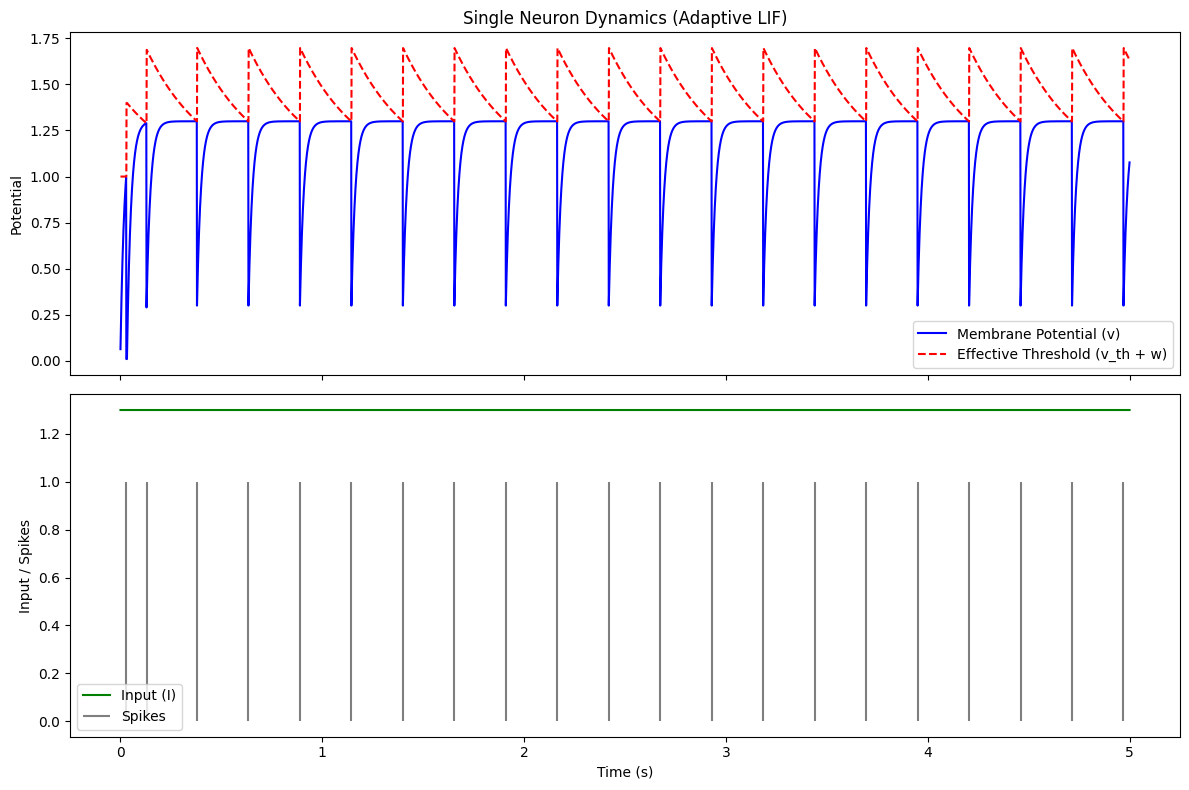

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import subprocess

# Rebuild and run
subprocess.run(["cmake", "--build", "build"], capture_output=True)
subprocess.run(["./build/snn"], capture_output=True)

if os.path.exists("output.csv"):
    df = pd.read_csv("output.csv")
    df['time'] = df['step'] * 0.001

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(df['time'], df['v'], label='Membrane Potential (v)', color='blue')
    ax1.plot(df['time'], df['v_th_eff'], '--', label='Effective Threshold (v_th + w)', color='red')
    ax1.set_ylabel('Potential')
    ax1.legend()
    ax1.set_title('Single Neuron Dynamics (Adaptive LIF)')

    ax2.plot(df['time'], df['input'], label='Input (I)', color='green')
    ax2.vlines(df[df['spike'] > 0]['time'], 0, 1, color='black', alpha=0.5, label='Spikes')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Input / Spikes')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Error: output.csv not generated.")